In [ ]:
import logging
import os
import pickle
import random
import sys
from os.path import join

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xgboost as xgb
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import KFold

sys.path.append("./additional_code")
# from data_preprocessing import *
CURRENT_DIR = os.getcwd()
print(CURRENT_DIR)
our_data = CURRENT_DIR + "/../data/our_data/"

/home/hanxd/Repositories/ESP/our_codes


In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
anotherdata = pd.read_csv(our_data + "ginnascores.txt", sep="\t", header=0)

In [ ]:
result = anotherdata["complex_name"].str.split(r"_", expand=True)
result.columns = ["enzyme", "substrate", "cc"]
result["substrate_cc"] = result["substrate"] + result["cc"]

anotherdata = pd.concat([anotherdata, result], axis=1)

ourdata = pd.read_pickle(join(CURRENT_DIR, "..", "data", "our_data", "5foldsdata.pkl"))

In [ ]:
print(anotherdata["enzyme"].nunique())
print(anotherdata["substrate"].nunique())
print(ourdata["enzyme"].nunique())
print(ourdata["substrate"].nunique())

294
252
408
228


In [ ]:
anotherdata[anotherdata["enzyme"] == "CYP707A1"]

,complex_name,wei_score,if_right,enzyme,substrate,cc,substrate_cc
0,CYP707A1_08Y_C22,0.345,1,CYP707A1,08Y,C22,08YC22
402,CYP707A1_0GV_C18,0.252,1,CYP707A1,0GV,C18,0GVC18
452,CYP707A1_0QA_C9,0.483,1,CYP707A1,0QA,C9,0QAC9
750,CYP707A1_12H_C7,0.423,1,CYP707A1,12H,C7,12HC7
1091,CYP707A1_1CA_C11,0.253,1,CYP707A1,1CA,C11,1CAC11
...,...,...,...,...,...,...,...
74184,CYP707A1_BAM_C27,0.307,1,CYP707A1,BAM,C27,BAMC27
74348,CYP707A1_EY5_C3,0.235,1,CYP707A1,EY5,C3,EY5C3
74566,CYP707A1_ADI_C14,0.380,1,CYP707A1,ADI,C14,ADIC14
74848,CYP707A1_AGI_C9,0.364,1,CYP707A1,AGI,C9,AGIC9


In [ ]:
with open(our_data + "cache/gnina.pkl", "wb") as file:
    pickle.dump(anotherdata["enzyme"].unique(), file)

In [ ]:
result = anotherdata.merge(
    ourdata[["enzyme", "substrate", "scores"]], on=["enzyme", "substrate"], how="left"
)
result = result.dropna()
result.to_pickle(our_data + "combdata.pkl")

In [ ]:
print(result["enzyme"].nunique())
print(result["substrate"].nunique())
print(result["complex_name"].nunique())
print(result["substrate_cc"].nunique())

225
199
47362
257


In [ ]:
with open(our_data + "cache/result.pkl", "wb") as file:
    pickle.dump(result["enzyme"].unique(), file)

In [10]:
# relist = result.groupby('substrate_cc')['enzyme'].nunique().reset_index()
# relist2 = result.groupby('substrate')['enzyme'].nunique().reset_index()

In [ ]:
ourdata_N = ourdata.sort_values(by=["substrate", "scores"], ascending=[True, False])
ourdata_N["ranking"] = ourdata_N.groupby("substrate").cumcount() + 1
df1ranking3 = ourdata_N[ourdata_N["Binding"] == 1]["ranking"] / 227
print(df1ranking3.median())

0.1277533039647577


In [ ]:
for i in range(0, 101):
    result["scores" + str(i)] = (
        result["wei_score"] * i / 100 + result["scores"] * (100 - i) / 100
    )
    result["rank" + str(i)] = result.groupby("substrate_cc")["scores" + str(i)].rank(
        method="first", ascending=False
    )

In [ ]:
ratios_list = []

binding_1_values = result[result["if_right"] == 2]
for i in range(0, 101):
    binding_1_values["ranking" + str(i)] = binding_1_values["rank" + str(i)] / 227
    ratios_list.append([i, binding_1_values["ranking" + str(i)].median()])
ratios_df = pd.DataFrame(ratios_list, columns=["i", "median"])

In [14]:
ratios_df

,i,median
0,0,0.072687
1,1,0.070485
2,2,0.070485
3,3,0.070485
4,4,0.070485
...,...,...
96,96,0.050661
97,97,0.055066
98,98,0.061674
99,99,0.063877


In [ ]:
ratios_df.sort_values(by="median", ascending=True)

,i,median
76,76,0.035242
81,81,0.035242
82,82,0.035242
84,84,0.035242
85,85,0.035242
...,...,...
3,3,0.070485
2,2,0.070485
1,1,0.070485
0,0,0.072687


In [ ]:
ratios_df.sort_values(by="median", ascending=True).to_csv(our_data + "bin/scores.csv")

<Figure size 1000x600 with 0 Axes>

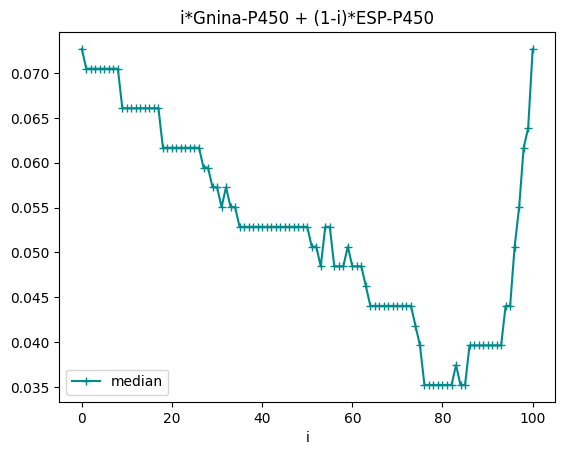

In [ ]:
plt.figure(figsize=(10, 6))
ratios_df.plot(
    x="i",
    y="median",
    kind="line",
    title="i*Gnina-P450 + (1-i)*ESP-P450",
    marker="+",
    color="#008B8B",
)

plt.show()

In [19]:
result

,complex_name,wei_score,if_right,enzyme,substrate,cc,substrate_cc,scores,scores0,rank0,...,scores96,rank96,scores97,rank97,scores98,rank98,scores99,rank99,scores100,rank100
2669,CYP72A66v2_ABA_C14,0.530,1,CYP72A66v2,ABA,C14,ABAC14,0.297941,0.297941,51.0,...,0.520718,1.0,0.523038,1.0,0.525359,1.0,0.527679,1.0,0.530,1.0
2670,CYP72A7_ABA_C14,0.513,1,CYP72A7,ABA,C14,ABAC14,0.103160,0.103160,144.0,...,0.496606,2.0,0.500705,2.0,0.504803,2.0,0.508902,2.0,0.513,2.0
2671,CYP72A62v2_ABA_C14,0.487,1,CYP72A62v2,ABA,C14,ABAC14,0.223932,0.223932,71.0,...,0.476477,4.0,0.479108,4.0,0.481739,4.0,0.484369,4.0,0.487,4.0
2673,CYP707A1_ABA_C14,0.418,1,CYP707A1,ABA,C14,ABAC14,0.015169,0.015169,204.0,...,0.401887,24.0,0.405915,24.0,0.409943,24.0,0.413972,23.0,0.418,21.0
2674,CYP72A475_ABA_C14,0.451,1,CYP72A475,ABA,C14,ABAC14,0.101858,0.101858,145.0,...,0.437034,8.0,0.440526,7.0,0.444017,7.0,0.447509,7.0,0.451,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75056,CYP72A610_AHT_C8,0.300,1,CYP72A610,AHT,C8,AHTC8,0.057208,0.057208,2.0,...,0.290288,6.0,0.292716,6.0,0.295144,7.0,0.297572,7.0,0.300,8.0
75057,CYP74L1_AHT_C8,0.249,1,CYP74L1,AHT,C8,AHTC8,0.040597,0.040597,7.0,...,0.240664,10.0,0.242748,10.0,0.244832,10.0,0.246916,10.0,0.249,9.0
75058,CYP79A12_AHT_C8,0.248,1,CYP79A12,AHT,C8,AHTC8,0.158764,0.158764,1.0,...,0.244431,9.0,0.245323,9.0,0.246215,9.0,0.247108,9.0,0.248,10.0
75059,CYP71D12_AHT_C8,0.229,1,CYP71D12,AHT,C8,AHTC8,0.045258,0.045258,6.0,...,0.221650,12.0,0.223488,12.0,0.225325,12.0,0.227163,12.0,0.229,12.0


In [ ]:
result.to_csv(our_data + "cache/allscores.csv")

In [ ]:
binding_1_values.to_csv(our_data + "cache/truecores.csv")

In [ ]:
binding_1_values.to_pickle(our_data + "true_combine_cores.pkl")